# Task 1

## smile dataset

### visualization

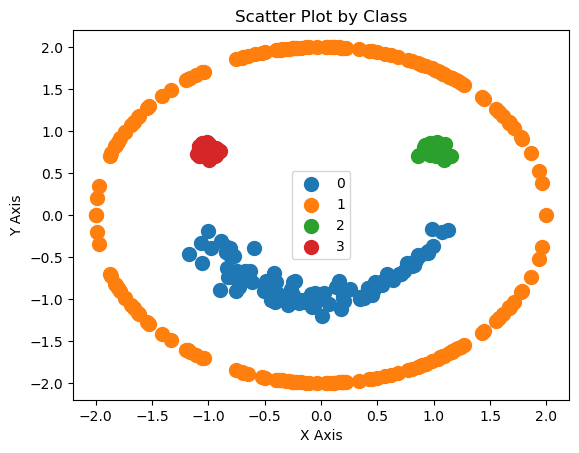

In [14]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_data(file_path, data_type):
    data_dict = {}
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if data_type == "csv":
                x, y, cl = line.split(',')
            else:
                x, y, cl = line.split()
            if cl not in data_dict:
                data_dict[cl] = ([], [])
            data_dict[cl][0].append(float(x))
            data_dict[cl][1].append(float(y))
    fig, ax = plt.subplots()

    for label, (x, y) in data_dict.items():
        ax.scatter(x, y, label=label, s=100)

    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_title('Scatter Plot by Class')
    ax.legend()
    plt.show()

plot_data("./data/smile.csv", "csv")



### standardization


In [28]:
from sklearn.preprocessing import StandardScaler
import io

scaler = StandardScaler()
data_path = "./data/smile.csv"
with open(data_path, 'r') as f:
    data_str = f.read()
df = pd.read_csv(io.StringIO(data_str), header=None)
df.columns = ['x_coord', 'y_coord', 'class']
X = df.iloc[:, :2].values
X_scaled = scaler.fit_transform(X)

In [30]:
def show_results(labels, title):
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(title)
    plt.show()

### K-means

d:\Windows_Folders\FACULTATE\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


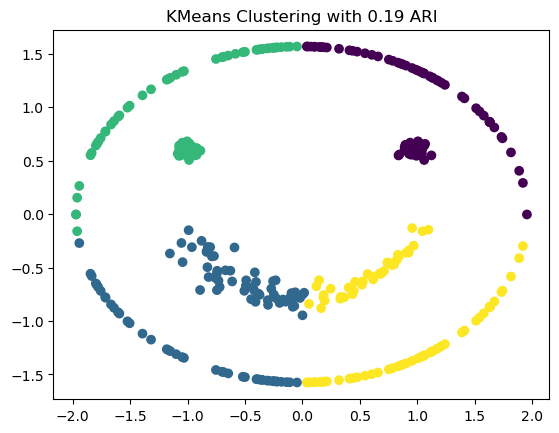

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


kmeans = KMeans(n_clusters=4)
kmeans_pred = kmeans.fit_predict(X_scaled)
ari = adjusted_rand_score(df['class'], kmeans_pred)
show_results(kmeans_pred, f"KMeans Clustering with {ari:.2f} ARI")


### EM (GaussianMixture)

d:\Windows_Folders\FACULTATE\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


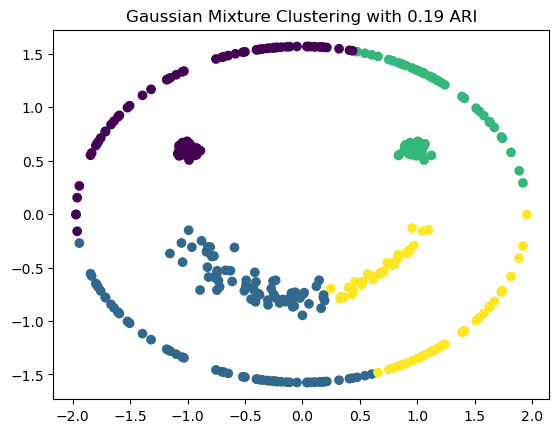

In [46]:
from sklearn.mixture import GaussianMixture


gaussina_mix = GaussianMixture(n_components=4)
gm_pred = gaussina_mix.fit_predict(X_scaled)
ari = adjusted_rand_score(df['class'], gm_pred)
show_results(gm_pred, f"Gaussian Mixture Clustering with {ari:.2f} ARI")

### Hierarchical (4 linkages)

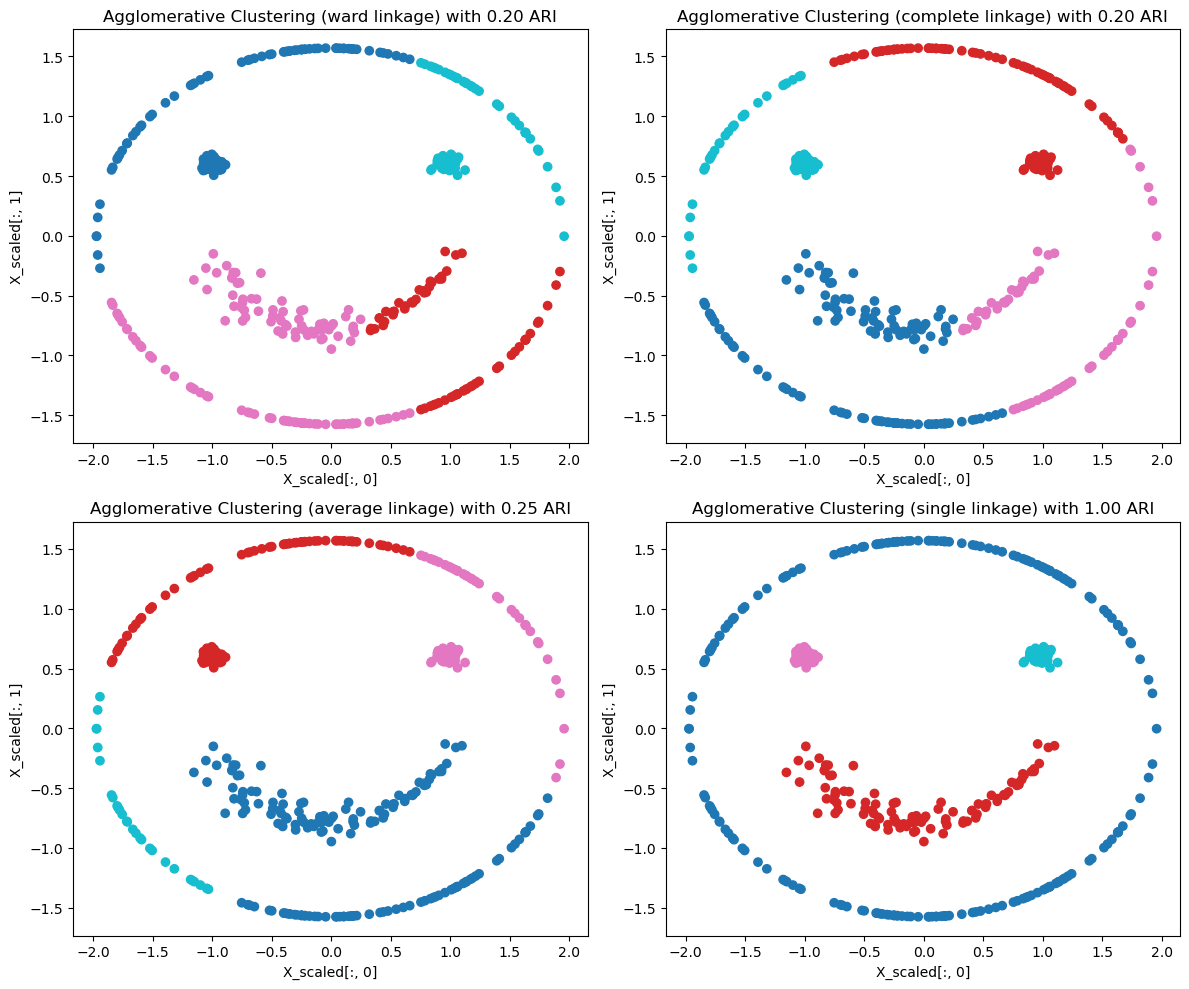

In [52]:
from sklearn.cluster import AgglomerativeClustering

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, linkage in enumerate(['ward', 'complete', 'average', 'single']):
    agglomerative_cl = AgglomerativeClustering(n_clusters=4, linkage=linkage)
    agglomerative_cl_pred = agglomerative_cl.fit_predict(X_scaled)
    ari = adjusted_rand_score(df['class'], agglomerative_cl_pred)

    ax = axes.flatten()[i]
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=agglomerative_cl_pred, cmap='tab10')
    ax.set_title(f"Agglomerative Clustering ({linkage} linkage) with {ari:.2f} ARI")
    ax.set_xlabel('X_scaled[:, 0]')
    ax.set_ylabel('X_scaled[:, 1]')

plt.tight_layout()
plt.show()


### DBSCAN

DBSCAN with euclidean distance:


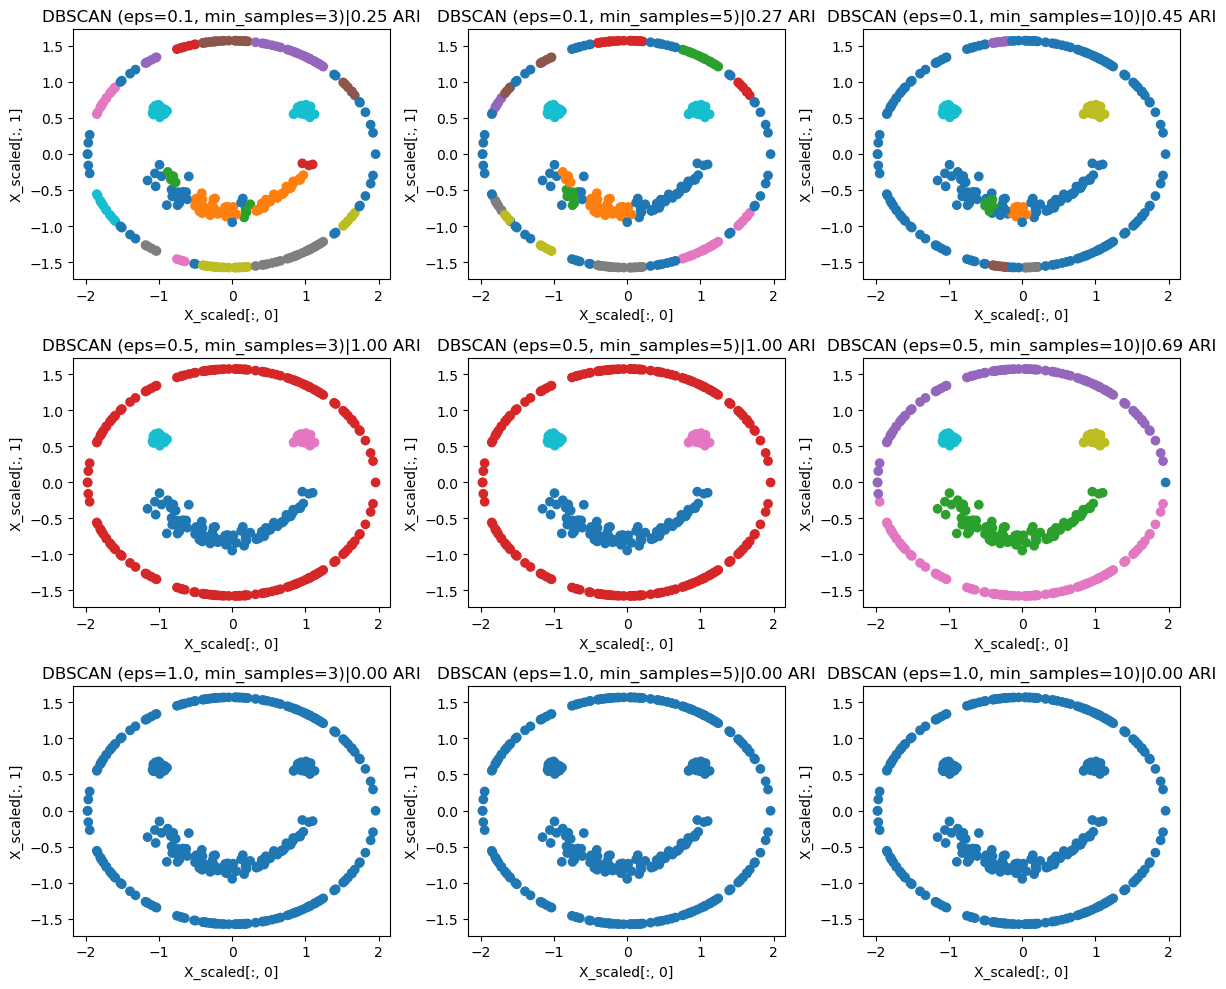

DBSCAN with manhattan distance:


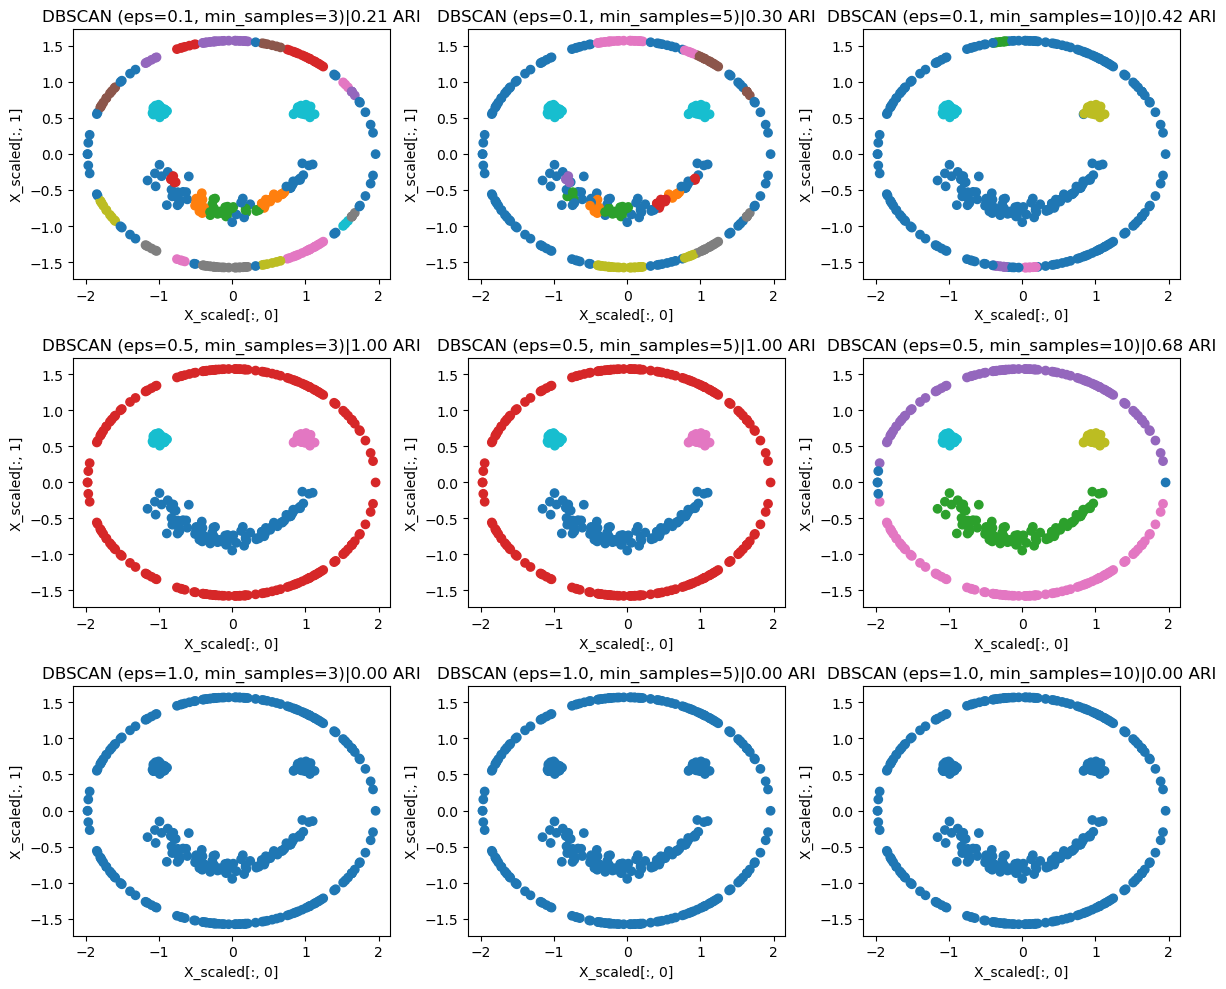

DBSCAN with chebyshev distance:


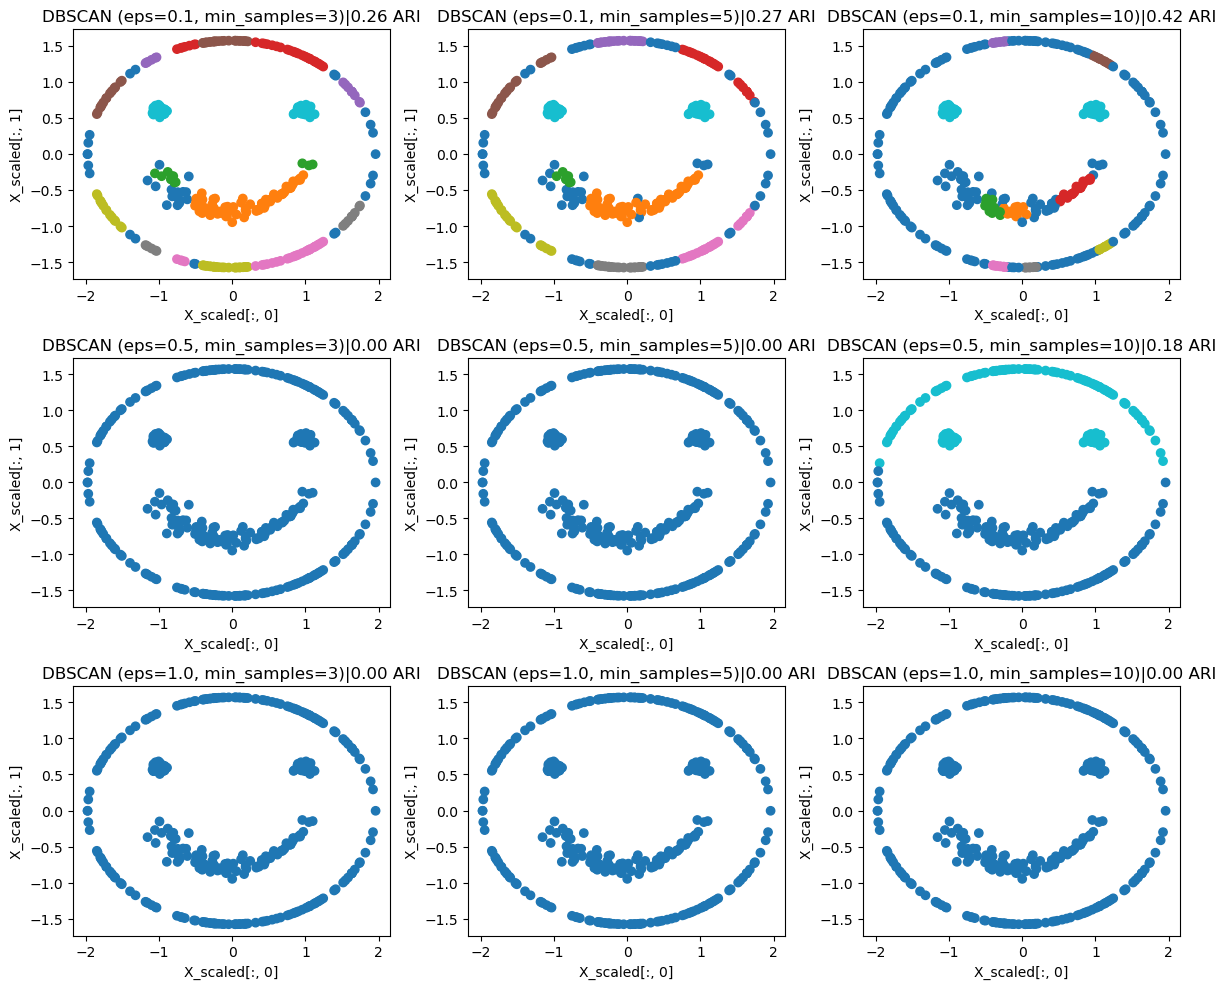

DBSCAN with cosine distance:


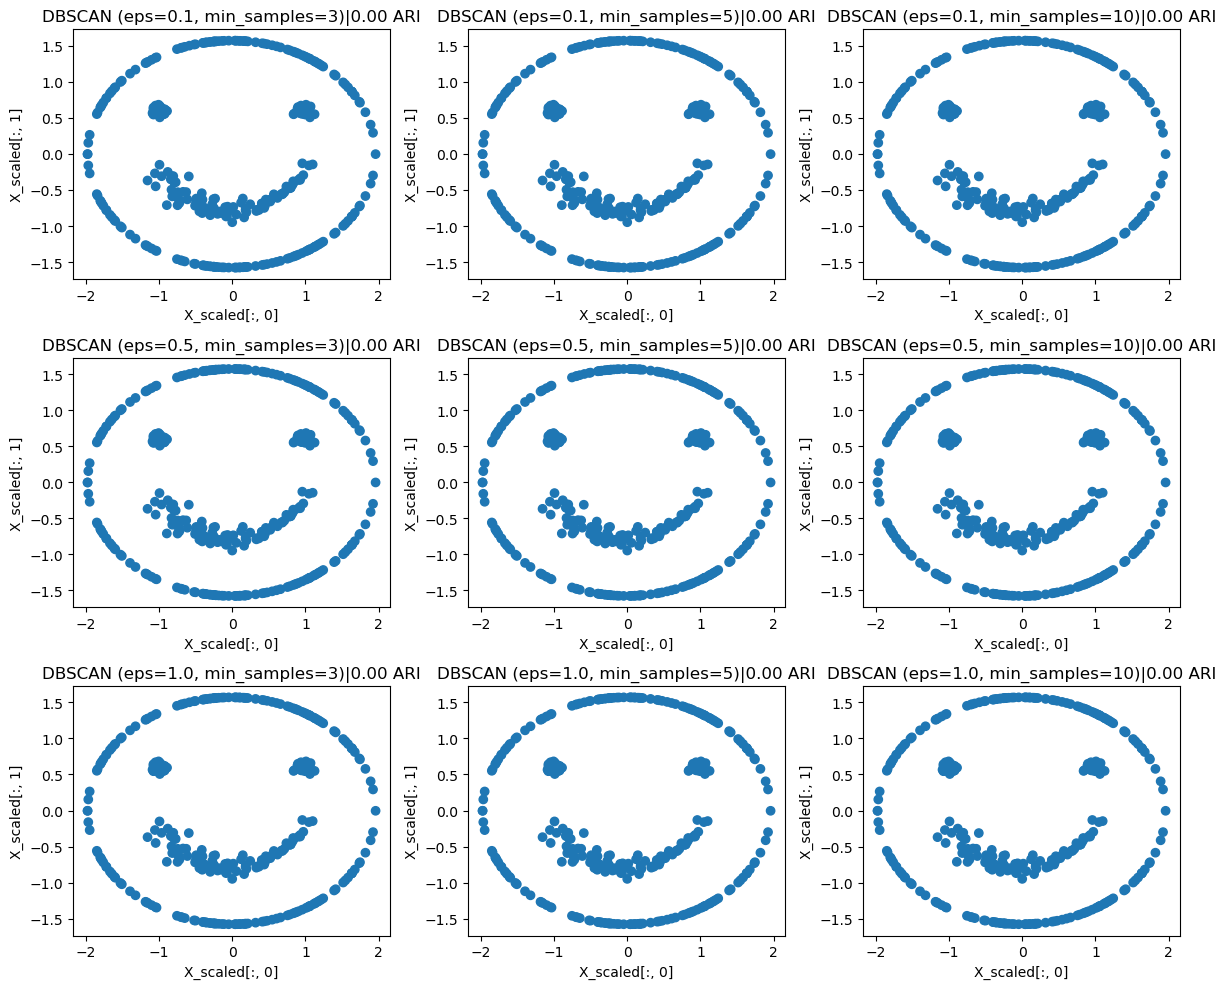

In [59]:
from sklearn.cluster import DBSCAN


for distance in ['euclidean', 'manhattan', 'chebyshev', 'cosine']:
    print(f"DBSCAN with {distance} distance:")
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))

    i = 0
    for eps in [0.1, 0.5, 1.0]:
        for min_samples in [3, 5, 10]:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=distance)
            dbscan_pred = dbscan.fit_predict(X_scaled)
            ari = adjusted_rand_score(df['class'], dbscan_pred)

            ax = axes.flatten()[i]
            i += 1
            ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_pred, cmap='tab10')
            ax.set_title(f"DBSCAN (eps={eps}, min_samples={min_samples})|{ari:.2f} ARI")
            ax.set_xlabel('X_scaled[:, 0]')
            ax.set_ylabel('X_scaled[:, 1]')

    plt.tight_layout()
    plt.show()

## 2d-10c dataset

### visualization


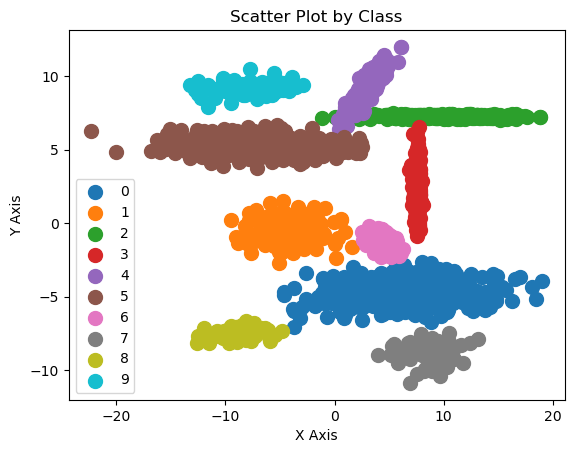

In [15]:
plot_data("./data/2d-10c.dat", "dat")


### K-means

### EM


### hierarchical 


### DBSCAN

## square dataset

### visualization

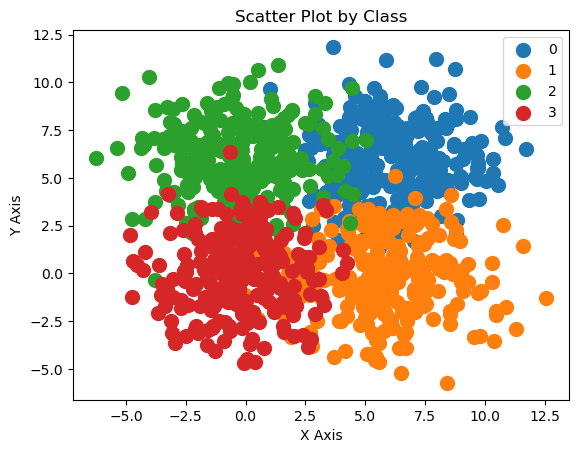

In [17]:
plot_data("./data/square.data", "data")

### K-means


### EM



### hierarchical 



### DBSCAN

## Iris dataset

### visualization


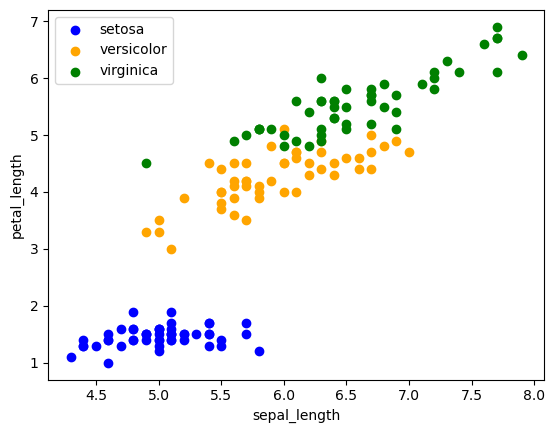

In [24]:
# source: https://medium.com/@xkyouhei/introduction-to-data-visualization-with-python-iris-dataset-a7d9be01c999
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('./data/iris.csv', header=None)

# Define color mapping for each species
colors = {'setosa': 'blue', 'versicolor': 'orange', 'virginica': 'green'}
# Define species names mapping
species_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

# Plot sepal length vs petal length for each species with different colors
for species, group in df.groupby(df[4]):
    name = species_names[species]
    plt.scatter(group[0], group[2], 
                color=colors[name], label=name)
# Set axis labels
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
# Show legend
plt.legend()

plt.show()

### K-means



### EM




### hierarchical 




### DBSCAN

### SOM

d:\Windows_Folders\FACULTATE\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Windows_Folders\FACULTATE\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


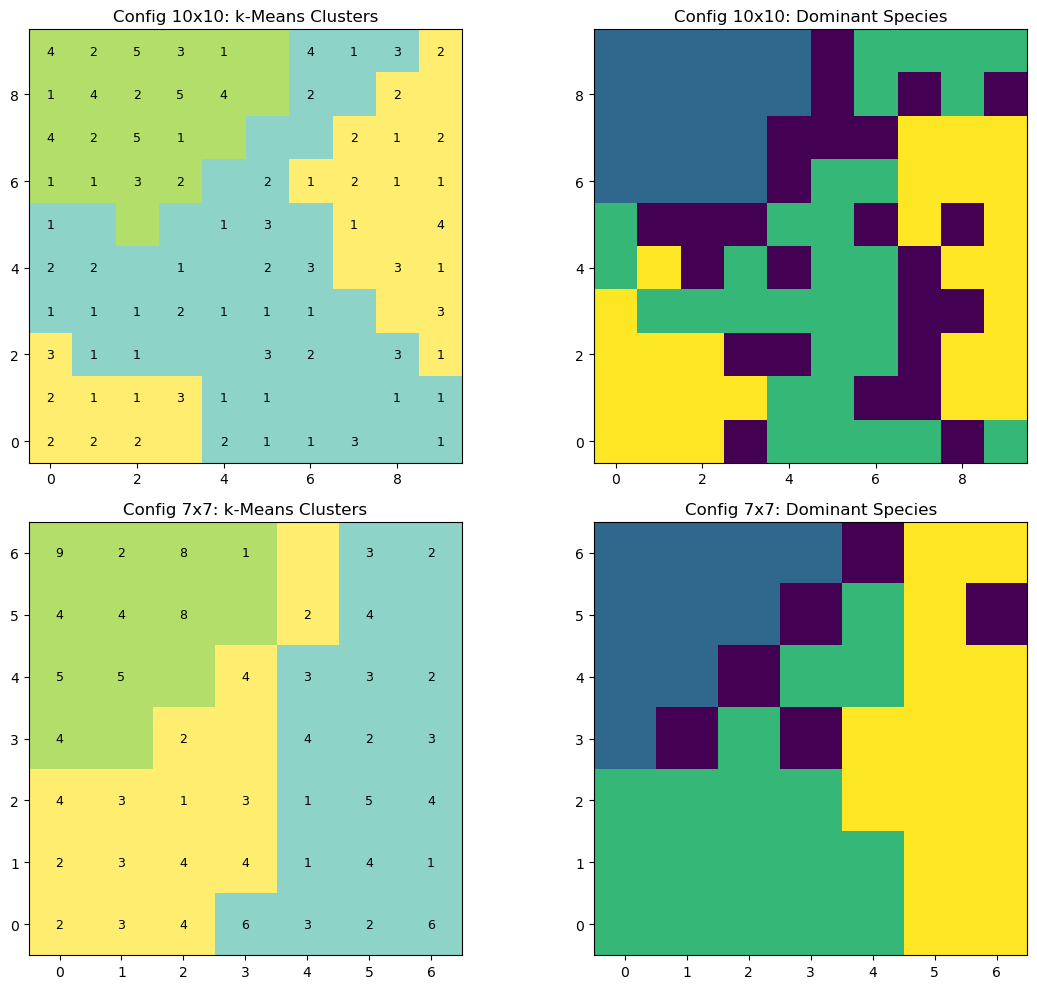

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import io


data_path = "./data/iris.csv"
with open(data_path, 'r') as f:
    data_str = f.read()
df = pd.read_csv(io.StringIO(data_str), header=None)
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
X = df.iloc[:, :4].values
y = df.iloc[:, 4].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 2. Simple SOM Implementation
class SimpleSOM:
    def __init__(self, x_size, y_size, input_dim, learning_rate=0.5, sigma=1.0):
        self.x_size, self.y_size = x_size, y_size
        self.input_dim = input_dim
        self.weights = np.random.rand(x_size, y_size, input_dim)
        self.lr_init, self.sigma_init = learning_rate, sigma
        
    def train(self, data, epochs=2000):
        yy, xx = np.meshgrid(np.arange(self.y_size), np.arange(self.x_size))
        grid = np.stack((xx, yy), axis=-1)
        for epoch in range(epochs):
            eta = self.lr_init * (1 - epoch / epochs)
            sigma = max(0.1, self.sigma_init * (1 - epoch / epochs))
            sample = data[np.random.randint(0, len(data))]
            dists = np.linalg.norm(self.weights - sample, axis=2)
            bmu_pos = np.array(np.unravel_index(np.argmin(dists), (self.x_size, self.y_size)))
            dist_sq = np.sum((grid - bmu_pos)**2, axis=2)
            influence = np.exp(-dist_sq / (2 * sigma**2))[:, :, np.newaxis]
            self.weights += eta * influence * (sample - self.weights)

    def get_bmu(self, x):
        dists = np.linalg.norm(self.weights - x, axis=2)
        return np.unravel_index(np.argmin(dists), (self.x_size, self.y_size))

# 3. Execution for 2 Configurations
configs = [(10, 10), (7, 7)]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (x_sz, y_sz) in enumerate(configs):
    # Train SOM
    som = SimpleSOM(x_sz, y_sz, 4)
    som.train(X_scaled)
    
    # k-Means on weights
    weights_flat = som.weights.reshape(-1, 4)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(weights_flat)
    clusters = kmeans.labels_.reshape(x_sz, y_sz)
    
    # Map data points
    mapping = np.zeros((x_sz, y_sz))
    class_dist = np.full((x_sz, y_sz), -1.0)
    hits = [[[] for _ in range(y_sz)] for _ in range(x_sz)]
    for i, x in enumerate(X_scaled):
        bmu = som.get_bmu(x)
        mapping[bmu] += 1
        hits[bmu[0]][bmu[1]].append(y[i])

    # Visualization
    ax_clus = axes[idx, 0]
    ax_clus.imshow(clusters, cmap='Set3', origin='lower')
    ax_clus.set_title(f"Config {x_sz}x{y_sz}: k-Means Clusters")
    for i in range(x_sz):
        for j in range(y_sz):
            if mapping[i, j] > 0:
                ax_clus.text(j, i, int(mapping[i, j]), ha='center', va='center', fontsize=9)

    ax_data = axes[idx, 1]
    for i in range(x_sz):
        for j in range(y_sz):
            if hits[i][j]: class_dist[i, j] = np.bincount(hits[i][j]).argmax()
    im = ax_data.imshow(class_dist, cmap='viridis', origin='lower', vmin=-1, vmax=2)
    ax_data.set_title(f"Config {x_sz}x{y_sz}: Dominant Species")

plt.tight_layout()
plt.savefig('som_iris_analysis.png')

# Task 2

source: https://www.youtube.com/watch?v=iNlZ3IU5Ffw

# Task 3